# Reproducible Design & Analytical Framework: Common-Source Amplifier (VN2222LL)

**Course:** EL2205 Major Assignment  
**Institution:** Electrical Engineering Study Program, Bandung Institute of Technology (ITB)  
**Author:** Benedictus Kenneth Setiadi (13224003)  
**Date:** April 2026

---

## 1. Executive Summary

This document details a comprehensive, reproducible methodology for the design and analysis of a Common-Source voltage amplifier utilizing a discrete VN2222LL NMOS transistor. To mitigate the propagation of quantization and rounding errors during iterative design phases, all computational analyses are executed utilizing 64-bit floating-point precision. This rigorous numerical approach ensures theoretical fidelity, minimizing analytical deviations prior to empirical laboratory validation.

## 2. Design Constraints & Target Specifications

Governed by the assignment parameters, the amplifier architecture must strictly satisfy the following performance metrics:

* **Amplifier Topology:** Common-Source
* **Small-Signal Voltage Gain ($A_v$):** 10 V/V (20 dB)
* **Input Resistance ($R_{in}$):** 27 kΩ
* **Output Resistance ($R_{out}$):** 1.5 kΩ
* **Nominal Supply Voltage ($V_{DD}$):** 12.0 V

## 3. Architectural Topology & Circuit Schematic

The proposed design employs a Common-Source architecture augmented with Partial Source Degeneration. This specific topology introduces localized negative feedback, which inherently stabilizes the quiescent DC operating point (Q-point) against thermal drift and device parameter variations. Simultaneously, the partial AC bypass configuration preserves small-signal linearity independent of inherent transconductance ($g_m$) fluctuations.

<p align="center">
<img src="/notebook/assets/schematic.png" alt="Circuit Schematic" width="600"/>
<br>
<i>Figure 1: Final synthesized schematic of the VN2222LL amplifier circuit.</i>
</p>

## 4. Analytical Methodology & Simulation Flow

The evaluation of the amplifier follows a progressive, two-stage analytical framework: **Ideal Baseline Characterization** followed by **Non-Ideal System Verification**.

1. **Baseline Characterization:** The circuit is initially analyzed under idealized conditions. This sequential phase encompasses DC operating point verification (Q-Point stability), mid-band small-signal gain extraction, full-spectrum frequency response mapping (Bode Plot), and time-domain transient analysis to confirm phase inversion and signal integrity.
2. **Real-World Constraint Modeling:** Once the idealized baseline parameters are established, the simulation environment is subjected to practical constraints. Output loading effects ($R_L$) are introduced to measure initial gain degradation. Finally, the model is augmented with resistive parasitics—specifically capacitor Equivalent Series Resistance (ESR) and trace impedances—to strictly analyze the resulting deviations in mid-band voltage gain and input signal attenuation.

<p align="center">
<img src="/notebook/assets/sim_flowchart.png" alt="Simulation Flowchart" width="500"/>
<br>
<i>Figure 2: Sequential flowchart detailing the progressive simulation methodology, from baseline characterization to parasitic degradation analysis.</i>
</p>

<p align="center">
<img src="/notebook/assets/design_flowchart.svg" alt="Design Flowchart" width="400"/>
<br>
<i>Figure 2: Sequential flowchart detailing the backward-propagation design methodology.</i>
</p>

## 5. Automated Computational Framework

The subsequent computational blocks sequentially execute the analytical derivations required for the design. Fundamental silicon extraction parameters—specifically Threshold Voltage ($V_{th}$), Process Transconductance Parameter ($K_n$), and Channel-Length Modulation coefficient ($\lambda$)—are decoupled and parameterized globally. This modular architectural approach ensures that the computational engine can instantaneously recalculate all passive component values upon the acquisition of updated empirical laboratory measurements.

---

## Baseline Exact Calculation & E24 Standardization

**Objective:**
To derive the high-precision theoretical component values required to meet the target specifications and subsequently perform a controlled mapping to the **E24 Standard Resistor Series**.

**Methodology:**
1. **High-Precision Synthesis:** Utilizing 64-bit floating-point computation to solve the simultaneous equations for $A_v$, $R_{in}$, and $R_{out}$. This minimizes numerical drift and ensures that the initial design point is mathematically perfect.
2. **E24 Conversion & Quantization:** The idealized calculated values are mapped to the nearest commercially available E24 resistors. 
3. **Tolerance & Deviation Analysis:** A secondary calculation is performed using these standardized values to quantify the "Quantization Error"—the theoretical shift in gain and impedance caused by using discrete, fixed-value components.

**Significance:**
By isolating this conversion phase, we can distinguish between performance drops caused by **component rounding** versus those caused by **loading effects** and **parasitics** in later phases. This establishes a "Practical Baseline" for all subsequent simulations.

In [1]:
%pip install PyLTSpice matplotlib numpy pandas scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd

In [3]:
import os
import numpy as np
import pandas as pd

# Matikan warning Pandas biar output notebook bersih
pd.set_option('future.no_silent_downcasting', True)

# ==============================================================================
# BLOK 1: PARAMETER KONSTAN & TARGET SPESIFIKASI (UBAH DI SINI)
# ==============================================================================
# Parameter MOSFET (Contoh: hasil rata-rata tes lab dari 10 orang)
V_TH = np.float64(1.529)         # Threshold Voltage (V)
K_N  = np.float64(15.95e-3)      # Parameter Konduksi (A/V^2) 1/2 * μ_n * C_ox * (W/L)
LAMBDA = np.float64(0.0234)      # Parameter Modulasi Panjang Kanal (V^-1)

# Spesifikasi Target & Asumsi Desain
V_DD = np.float64(12.0)          # Tegangan Supply (V)
TARGET_AV = np.float64(10.0)     # Magnitude Gain |Av| (V/V) setara 20dB
TARGET_ROUT = np.float64(1500.0) # Target Rout (Ohm)
TARGET_RIN = np.float64(27000.0) # Target Rin (Ohm)

# Asumsi awal untuk ruang swing
TARGET_VD = np.float64(7.2)      
TARGET_VS = np.float64(1.5)


# ==============================================================================
# BLOK 2: FUNGSI HELPER (SOLVER & E24 MATCHER)
# ==============================================================================
def get_closest_e24(val):
    """Mencari nilai resistor standar E24 terdekat dengan presisi tinggi."""
    e24_series = np.array([1.0, 1.1, 1.2, 1.3, 1.5, 1.6, 1.8, 2.0, 2.2, 2.4, 
                           2.7, 3.0, 3.3, 3.6, 3.9, 4.3, 4.7, 5.1, 5.6, 6.2, 
                           6.8, 7.5, 8.2, 9.1, 10.0], dtype=np.float64)
    if val <= 0: return np.float64(0)

    power = np.floor(np.log10(val))
    base_val = val / (np.float64(10)**power)
    
    idx = (np.abs(e24_series - base_val)).argmin()
    res = e24_series[idx] * (np.float64(10)**power)
    
    return np.float64(res)

def solve_bias_id(v_g, r_s_tot):
    """
    Menyelesaikan persamaan kuadrat I_D akibat feedback DC dari R_S.
    Mengasumsikan pendekatan tanpa Lambda untuk estimasi hand-calc.
    """
    a = K_N * (r_s_tot**2)
    b = -(np.float64(2.0) * K_N * r_s_tot * (v_g - V_TH) + np.float64(1.0))
    c = K_N * ((v_g - V_TH)**2)
    
    id_1 = (-b + np.sqrt(b**2 - np.float64(4.0)*a*c)) / (np.float64(2.0)*a)
    id_2 = (-b - np.sqrt(b**2 - np.float64(4.0)*a*c)) / (np.float64(2.0)*a)
    
    vgs_1 = v_g - (id_1 * r_s_tot)
    return id_1 if vgs_1 > V_TH else id_2


# ==============================================================================
# BLOK 3: PERHITUNGAN JALUR 1 (MATEMATIKA EKSAK)
# ==============================================================================
# 1. Komponen & Bias Awal
RD_ex = np.float64(1600.0) 
ID_ex = (V_DD - TARGET_VD) / RD_ex
RStot_ex = TARGET_VS / ID_ex
VS_ex = ID_ex * RStot_ex
VD_ex = V_DD - (ID_ex * RD_ex)

# 2. Parameter Sinyal Kecil Eksak (FIX: Efek Lambda dimasukkan ke VGS)
VDS_ex = VD_ex - VS_ex
VGS_ex = np.sqrt(ID_ex / (K_N * (np.float64(1.0) + LAMBDA * VDS_ex))) + V_TH
gm_ex = (np.float64(2.0) * ID_ex) / (VGS_ex - V_TH)
ro_ex = np.float64(1.0) / (LAMBDA * ID_ex)

# 3. Resistor Jaringan AC & DC Eksak
numerator = (gm_ex * ro_ex * RD_ex) - (TARGET_AV * (RD_ex + ro_ex))
denominator = TARGET_AV * (1.0 + (gm_ex * ro_ex))
RS1_ex = numerator / denominator
RS2_ex = RStot_ex - RS1_ex

# 4. Resistor Input Eksak
VG_ex = VGS_ex + TARGET_VS
R1_ex = V_DD * (TARGET_RIN / VG_ex)
R2_ex = (R1_ex * TARGET_RIN) / (R1_ex - TARGET_RIN)

# 5. Output Eksak (Double Check)
Rin_ex = (R1_ex * R2_ex) / (R1_ex + R2_ex)
Rout_drain_ex = ro_ex + RS1_ex + (gm_ex * ro_ex * RS1_ex)
Rout_ex = (RD_ex * Rout_drain_ex) / (RD_ex + Rout_drain_ex)
Av_ex = (gm_ex * ro_ex * RD_ex) / (RD_ex + RS1_ex + ro_ex + (gm_ex * ro_ex * RS1_ex))


# ==============================================================================
# BLOK 4: PERHITUNGAN JALUR 2 (REALITA FISIKA - E24)
# ==============================================================================
# 1. Konversi ke standar komponen pasaran
RD_e24  = get_closest_e24(RD_ex)
RS1_e24 = get_closest_e24(RS1_ex)
RS2_e24 = get_closest_e24(RS2_ex)
R1_e24  = get_closest_e24(R1_ex)
R2_e24  = get_closest_e24(R2_ex)

# 2. Pergeseran Bias DC akibat E24
VG_e24 = V_DD * (R2_e24 / (R1_e24 + R2_e24))
RStot_e24 = RS1_e24 + RS2_e24
ID_e24 = solve_bias_id(VG_e24, RStot_e24)

VS_e24 = ID_e24 * RStot_e24
VD_e24 = V_DD - (ID_e24 * RD_e24)
VGS_e24 = VG_e24 - VS_e24

# 3. Pergeseran Parameter Sinyal Kecil akibat ID baru
gm_e24 = (np.float64(2.0) * ID_e24) / (VGS_e24 - V_TH)
ro_e24 = np.float64(1.0) / (LAMBDA * ID_e24)

# 4. Finalisasi Output AC dengan model E24
Rin_e24 = (R1_e24 * R2_e24) / (R1_e24 + R2_e24)
Rout_drain_e24 = ro_e24 + RS1_e24 + (gm_e24 * ro_e24 * RS1_e24)
Rout_e24 = (RD_e24 * Rout_drain_e24) / (RD_e24 + Rout_drain_e24)
Av_e24 = (gm_e24 * ro_e24 * RD_e24) / (RD_e24 + RS1_e24 + ro_e24 + (gm_e24 * ro_e24 * RS1_e24))


# ==============================================================================
# BLOK 5: UJI KETAHANAN AUTO-CORRECT (MENGGUNAKAN BIAS E24)
# ==============================================================================
ID_50mV  = solve_bias_id(VG_e24 + np.float64(0.05), RStot_e24)
ID_200mV = solve_bias_id(VG_e24 + np.float64(0.20), RStot_e24)
ID_500mV = solve_bias_id(VG_e24 + np.float64(0.50), RStot_e24)


# ==============================================================================
# BLOK 6: KALKULASI GALAT, RENDER TABEL & EXPORT CSV
# ==============================================================================
def calc_err(target, actual):
    return np.abs(target - actual) / target * 100

data = [
    # KOMPONEN RESISTOR
    ("Komponen", "R_D (Ohm)", "-", RD_ex, RD_e24, "-", "-"),
    ("Komponen", "R_S1 (Ohm)", "-", RS1_ex, RS1_e24, "-", "-"),
    ("Komponen", "R_S2 (Ohm)", "-", RS2_ex, RS2_e24, "-", "-"),
    ("Komponen", "R_1 (Ohm)", "-", R1_ex, R1_e24, "-", "-"),
    ("Komponen", "R_2 (Ohm)", "-", R2_ex, R2_e24, "-", "-"),
    
    # BIAS DC
    ("Bias DC", "V_G (V)", "-", VG_ex, VG_e24, "-", "-"),
    ("Bias DC", "V_S (V)", TARGET_VS, VS_ex, VS_e24, "-", "-"),
    ("Bias DC", "V_D (V)", TARGET_VD, VD_ex, VD_e24, "-", "-"),
    ("Bias DC", "V_GS (V)", "-", VGS_ex, VGS_e24, "-", "-"),
    ("Bias DC", "I_D (mA)", "-", ID_ex * 1000, ID_e24 * 1000, "-", "-"),
    
    # PARAMETER SMALL SIGNAL
    ("Sinyal Kecil", "g_m (A/V)", "-", gm_ex, gm_e24, "-", "-"),
    ("Sinyal Kecil", "r_o (Ohm)", "-", ro_ex, ro_e24, "-", "-"),
    
    # PERFORMA AC
    ("Performa AC", "R_in (Ohm)", TARGET_RIN, Rin_ex, Rin_e24, calc_err(TARGET_RIN, Rin_ex), calc_err(TARGET_RIN, Rin_e24)),
    ("Performa AC", "R_out (Ohm)", TARGET_ROUT, Rout_ex, Rout_e24, calc_err(TARGET_ROUT, Rout_ex), calc_err(TARGET_ROUT, Rout_e24)),
    ("Performa AC", "Gain |A_v| (V/V)", TARGET_AV, Av_ex, Av_e24, calc_err(TARGET_AV, Av_ex), calc_err(TARGET_AV, Av_e24)),
    
    # TEST AUTO-CORRECTION DC
    ("Uji Stabilitas", "I_D (+50mV dVg)", "-", "-", ID_50mV * 1000, "-", "-"),
    ("Uji Stabilitas", "I_D (+200mV dVg)", "-", "-", ID_200mV * 1000, "-", "-"),
    ("Uji Stabilitas", "I_D (+500mV dVg)", "-", "-", ID_500mV * 1000, "-", "-")
]

df = pd.DataFrame(data, columns=["Kategori", "Parameter", "Target", "Hasil Eksak", "Hasil E24", "Galat Eksak (%)", "Galat E24 (%)"])

# Formatting output
pd.options.display.float_format = '{:.6f}'.format
df_print = df.replace("-", np.nan).fillna("-")

# ---------------------------------------------------------
# BIKIN FOLDER & EXPORT CSV
# ---------------------------------------------------------
output_dir = "./export_data/baseline"
os.makedirs(output_dir, exist_ok=True) # Bikin folder kalau belum ada
csv_filename = f"{output_dir}/Summary_Exact Mathematical Calculations_CS_Amp_Baseline.csv"

# Export dataframe aslinya (biar data '-' tetap bersih atau bisa dibaca Excel)
df.to_csv(csv_filename, index=False)

print(f"📁 FOLDER DAN FILE BERHASIL DIBUAT!")
print(f"✅ Data diekspor ke : {csv_filename}\n")

print("="*105)
print(f"{'RINGKASAN PERHITUNGAN REPRODUCIBLE (EKSAK VS E24)':^105}")
print("="*105)
print(df_print.to_string(index=False))

📁 FOLDER DAN FILE BERHASIL DIBUAT!
✅ Data diekspor ke : ./export_data/baseline/Summary_Exact Mathematical Calculations_CS_Amp_Baseline.csv

                            RINGKASAN PERHITUNGAN REPRODUCIBLE (EKSAK VS E24)                            
      Kategori        Parameter       Target  Hasil Eksak    Hasil E24 Galat Eksak (%) Galat E24 (%)
      Komponen        R_D (Ohm)            -  1600.000000  1600.000000               -             -
      Komponen       R_S1 (Ohm)            -    84.077694    82.000000               -             -
      Komponen       R_S2 (Ohm)            -   415.922306   430.000000               -             -
      Komponen        R_1 (Ohm)            - 94285.450421 91000.000000               -             -
      Komponen        R_2 (Ohm)            - 37834.437392 39000.000000               -             -
       Bias DC          V_G (V)            -     3.436373     3.600000               -             -
       Bias DC          V_S (V)     1.500000   

## SPICE SIMULATION BASELINE (NO LOAD AND PARASITICS)

In [1]:
!open -a LTspice "./sim_assets/baseline/CS_Amp_Baseline.asc"
!open -a LTspice "./sim_assets/load_effect/CS_Amp_Baseline_LoadEffect.asc"
!open -a LTspice "./sim_assets/parasitics/CS_Amp_Baseline_LoadEffect_Parasitics.asc"


# System Verification & Performance Validation Framework

This document outlines an automated, multi-phase verification pipeline for the Common-Source Amplifier design. Utilizing Python-driven data processing and headless LTspice simulations, this framework ensures that the physical circuit implementation strictly adheres to theoretical design constraints. To guarantee robust performance and systematically isolate discrepancies, the analytical pipeline is segregated into five distinct phases:

### Phase 1: Quiescent (DC) Bias & Small-Signal Parameter Extraction (.op)
**Objective:** Establish the baseline operating point (Q-point) utilizing quantized E24 resistor values. This phase extracts exact theoretical small-signal parameters—specifically transconductance ($g_m$) and output resistance ($r_o$)—directly from the SPICE Level 1 physics model to validate the expected voltage gain, input resistance ($R_{in}$), and output resistance ($R_{out}$).

### Phase 2: Time-Domain Transient Analysis (.tran)
**Objective:** Validate real-time signal integrity and dynamic range. This phase functions as a virtual oscilloscope to verify the 180-degree phase inversion inherent to the common-source topology, measure the practical peak-to-peak voltage gain ($V_{out(p-p)} / V_{in(p-p)}$), and ensure the output signal maintains linearity without entering saturation or cutoff regions (clipping).

### Phase 3: Frequency Response & Spectral Characterization (.ac)
**Objective:** Analyze the amplifier’s behavior across a comprehensive frequency spectrum. By executing a logarithmic AC sweep, this phase generates the Bode Plot to determine the maximum mid-band gain and identify the critical cutoff frequencies that define the system's effective bandwidth.

### Phase 4: Empirical AC Impedance Verification
**Objective:** Quantify the actual port impedances through simulation. By utilizing AC test sources and Thevenin equivalent principles within the SPICE environment, this phase empirically measures the input resistance ($R_{in}$) and output resistance ($R_{out}$), cross-referencing these simulated results against the analytical models derived in Phase 1.

### Phase 5: MOSFET Device Characteristics & Load Line Analysis (.dc)
**Objective:** Map the intrinsic physical boundaries of the active device. By generating the $I_D-V_{DS}$ (Output) and $I_D-V_{GS}$ (Transfer) characteristic curves and superimposing the actual Q-point onto them, this phase provides visual confirmation that the MOSFET is biased optimally and operates strictly within the saturation region.

# Phase 1: Quiescent (DC) Bias & Small-Signal Parameter Extraction

**Objective:**
To establish and verify the quiescent operating point (Q-point) of the common-source amplifier utilizing quantized E24 resistor networks. In this phase, pre-calculated design parameters are dynamically injected into the LTspice schematic and executed via a headless simulation environment. Critical small-signal parameters—specifically transconductance ($g_m$) and output resistance ($r_o$)—are subsequently extracted utilizing exact mathematical derivations based on the SPICE Level 1 physics model.

**Analytical Significance:**
Establishing a highly stable DC foundation is paramount. If the Q-point is not optimally centered within the MOSFET's saturation region, the amplifier will lack sufficient voltage headroom. This severely compromises the dynamic range, inevitably leading to asymmetrical clipping and harmonic distortion during the subsequent time-domain AC signal amplification.

In [5]:
import os
import numpy as np
import pandas as pd
from PyLTSpice import SimRunner, SpiceEditor, RawRead
from IPython.display import display, HTML

print("⚙️ [Phase 1] Executing DC Operating Point Analysis (.op)...")

# ===================================================================
# 1. PARAMETER INJECTION
# ===================================================================
my_params = {
    'my_VTO': V_TH,               
    'my_KP': K_N * 2,             
    'my_LAMBDA': LAMBDA,
    'RD_val': RD_e24,
    'RS1_val': RS1_e24,
    'RS2_val': RS2_e24,
    'R1_val': R1_e24,
    'R2_val': R2_e24,
    'Cin_val': "10u",
    'Cout_val': "10u",
    'Cs_val': "100u"
}

# ===================================================================
# 2. HEADLESS LTSPICE EXECUTION
# ===================================================================
mac_path = "/Applications/LTspice.app/Contents/MacOS/LTspice"
runner = SimRunner(output_folder='./sim_results/baseline/termin1', simulator=mac_path)

# Update netlist & run silently
netlist = SpiceEditor("./sim_assets/baseline/CS_Amp_Baseline_Termin1_copy.net") 
netlist.set_parameters(**my_params)
runner.run_now(netlist)

# ===================================================================
# 3. EXTRACTION, CALCULATION, & EXPORT
# ===================================================================
try:
    op_file = "sim_results/baseline/termin1/CS_Amp_Baseline_Termin1_copy_1.op.raw" 
    op_raw = RawRead(op_file)
    
    # Set Pandas to show maximum float precision natively
    pd.set_option('display.precision', 15)
    
    # --- A. FULL LTSPICE .OP DUMP (SCALED) ---
    all_op_data = []
    nodes = {}
    
    # Extract & scale automatically
    for var in op_raw.get_trace_names():
        val = np.real(op_raw.get_trace(var).get_wave()[0])
        nodes[var.lower()] = val
        
        # Kalau dia arus (diawali huruf 'i' atau 'I'), jadikan miliAmpere
        if var.lower().startswith('i'):
            all_op_data.append([var, val * 1000, "mA"])
        # Sisanya diasumsikan Tegangan (V)
        else:
            all_op_data.append([var, val, "V"])
            
    print("\n✅ === FULL LTSPICE DC OPERATING POINT (RAW DUMP) === ✅")
    df_all_op = pd.DataFrame(all_op_data, columns=['LTspice Variable', 'Value (Full Precision)', 'Unit'])
    display(HTML(df_all_op.to_html(index=False)))

    # ---------------------------------------------------------
    # EXPORT CSV RAW DUMP
    # ---------------------------------------------------------
    output_dir = "./export_data/baseline"
    os.makedirs(output_dir, exist_ok=True)
    csv_raw_filename = f"{output_dir}/Termin1_operating_point_baseline.csv"
    df_all_op.to_csv(csv_raw_filename, index=False)
    print(f"📁 RAW DATA EXPORTED TO: {csv_raw_filename}")

    # --- B. SUMMARY Q-POINT & SMALL-SIGNAL ---
    print("\n🔍 === EXACT PARAMETER SUMMARY (SPICE-BASED) === 🔍")
    
    # Extract Q-Point variables
    ID = nodes.get('id(m1)', 0.0)
    VGS = nodes.get('v(gate)', 0.0) - nodes.get('v(source)', 0.0)
    VDS = nodes.get('v(drain)', 0.0) - nodes.get('v(source)', 0.0)
    VOV = VGS - V_TH
    
    # Small-Signal parameters
    gm = (2 * ID) / VOV
    ro = 1 / (LAMBDA * ID) if LAMBDA > 0 else float('inf')
    Rin = (R1_e24 * R2_e24) / (R1_e24 + R2_e24)
    RD = RD_e24
    RS1 = RS1_e24

    # Gain & Rout Exact Formula
    numerator = - (gm * RD * ro)
    denominator = ro + RD + RS1 * (1 + gm * ro)
    Av_exact = numerator / denominator
    r_looking_into_drain = ro + RS1 + (gm * ro * RS1)
    Rout_exact = (RD * r_looking_into_drain) / (RD + r_looking_into_drain)

    # Gabungan Q-Point dan Parameter AC
    ss_results = [
        ["Operation Region", "Saturation 🟢" if VDS > VOV else "Triode / Cut-off 🔴", "-"],
        ["Drain Current (ID)", ID * 1000, "mA"],
        ["Gate-Source Voltage (VGS)", VGS, "V"],
        ["Drain-Source Voltage (VDS)", VDS, "V"],
        ["Overdrive Voltage (VOV)", VOV, "V"],
        ["Transconductance (gm)", gm * 1000, "mA/V"],
        ["Output Resistance (ro)", ro, "Ohm"],
        ["Input Resistance (Rin)", Rin, "Ohm"],
        ["Output Resistance (Rout)", Rout_exact, "Ohm"],
        ["Theoretical Gain (Av)", Av_exact, "V/V"]
    ]
    
    df_ss = pd.DataFrame(ss_results, columns=['Parameter', 'Calculated Value (Raw Float)', 'Unit'])
    display(HTML(df_ss.to_html(index=False)))

    # Export Summary CSV juga sekalian biar mantap
    csv_ss_filename = f"{output_dir}/Termin1_small_signal_baseline.csv"
    df_ss.to_csv(csv_ss_filename, index=False)
    print(f"📁 SUMMARY EXPORTED TO: {csv_ss_filename}\n")

    # Reset precision option
    pd.reset_option('display.precision')

except Exception as e:
    print(f"❌ Error during Phase 1: {e}")

⚙️ [Phase 1] Executing DC Operating Point Analysis (.op)...

✅ === FULL LTSPICE DC OPERATING POINT (RAW DUMP) === ✅


LTspice Variable,Value (Full Precision),Unit
V(drain),6.853135,V
V(gate),3.600000,V
V(source),1.646997,V
V(s_mid),1.383220,V
V(vdd),12.000000,V
V(vin),0.000000,V
V(vout),0.000069,V
Id(M1),3.216796,mA
Ig(M1),0.000000,mA
Ib(M1),-0.000000,mA


📁 RAW DATA EXPORTED TO: ./export_data/baseline/Termin1_operating_point_baseline.csv

🔍 === EXACT PARAMETER SUMMARY (SPICE-BASED) === 🔍


Parameter,Calculated Value (Raw Float),Unit
Operation Region,Saturation 🟢,-
Drain Current (ID),3.216796,mA
Gate-Source Voltage (VGS),1.953003,V
Drain-Source Voltage (VDS),5.206138,V
Overdrive Voltage (VOV),0.424003,V
Transconductance (gm),15.173456,mA/V
Output Resistance (ro),13284.971955,Ohm
Input Resistance (Rin),27300.000000,Ohm
Output Resistance (Rout),1518.720986,Ohm
Theoretical Gain (Av),-10.240086,V/V


📁 SUMMARY EXPORTED TO: ./export_data/baseline/Termin1_small_signal_baseline.csv



### Phase 2: Time-Domain Transient Analysis (.tran)

**Objective:**
To evaluate the real-time dynamic response and signal integrity of the amplifier architecture. In this phase, a 1 kHz sinusoidal test stimulus with a 20 mV peak amplitude is injected into the input terminal. The simulation functions as a highly precise virtual oscilloscope to empirically measure the practical voltage gain and observe the time-domain waveform characteristics.

**Analytical Verifications:**
1. **Gain Validation:** Quantifying the empirical peak-to-peak voltage gain ($V_{out(p-p)} / V_{in(p-p)}$) and rigorously correlating it with the theoretical small-signal derivations established in Phase 1.
2. **Phase Inversion:** Verifying the strict 180-degree phase shift characteristic inherent to the common-source inverting topology.
3. **Dynamic Headroom Integrity:** Confirming that the amplified output signal oscillates symmetrically around the quiescent DC bias point without inducing harmonic distortion, asymmetrical clipping, or driving the active device into the triode or cut-off regions.

*Methodological Note: The initial 2.0 milliseconds of the simulation data are intentionally truncated during data extraction to eliminate start-up transient artifacts and stabilization settling times associated with the passive RC coupling and bypass networks.*

🌊 [Phase 2] Executing Time-Domain Transient Analysis (.tran)...

✅ === TRANSIENT MEASUREMENT (STEADY-STATE) === ✅


Parameter,Measurement
Input Swing (Gate p-p),39.962 mV
Output Swing (Drain p-p),411.621 mV
Practical Gain |Av|,10.300 V/V


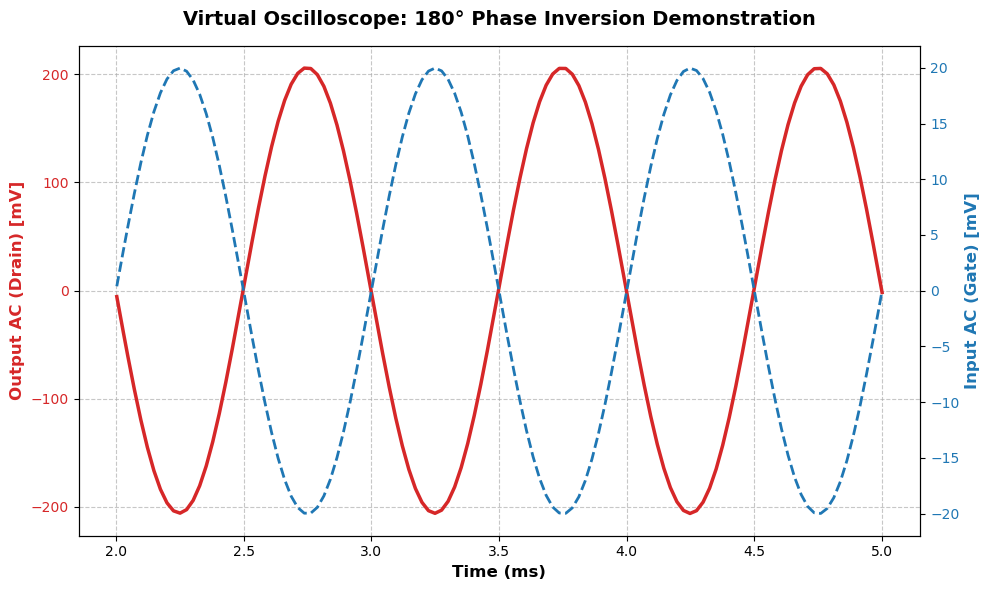


📁 FILES EXPORTED:
- Plot Image : ./export_data/baseline/Termin2_oscilloscope_plot_baseline.png
- Scope Data : ./export_data/baseline/Termin2_transient_waveforms_baseline.csv



In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PyLTSpice import SimRunner, SpiceEditor, RawRead
from IPython.display import display, HTML

print("🌊 [Phase 2] Executing Time-Domain Transient Analysis (.tran)...")

# ===================================================================
# 1. SETUP ENGINE & TARGET NETLIST
# ===================================================================
target_netlist = "./sim_assets/baseline/CS_Amp_Baseline_Termin2_copy.net" 
mac_path = "/Applications/LTspice.app/Contents/MacOS/LTspice"
runner = SimRunner(output_folder='./sim_results/baseline/termin2', simulator=mac_path)

# ===================================================================
# 2. INJECT PARAMETERS & RUN SILENTLY
# ===================================================================
editor = SpiceEditor(target_netlist)
editor.set_parameters(**my_params) 
runner.run_now(editor)

try:
    # ===================================================================
    # 3. ROBUST DATA EXTRACTION 
    # ===================================================================
    tran_file = "sim_results/baseline/termin2/CS_Amp_Baseline_Termin2_copy_1.raw"
    tran_raw = RawRead(tran_file)
    
    # HACK ANTI-ERROR: Coba get_axis(), kalau gagal, tarik trace 'time'
    try:
        time = tran_raw.get_axis()
        if time is None:
            time = tran_raw.get_trace("time").get_wave()
    except:
        time = tran_raw.get_trace("time").get_wave()

    # Pastikan semuanya dipaksa jadi bilangan Real (membuang sisa array complex)
    time = np.real(time)
    
    # Sesuaikan dengan nama node di .net lu (v(gate) dan v(drain) atau v(vin) dan v(vout))
    try:
        v_gate = np.real(tran_raw.get_trace("v(gate)").get_wave())
        v_drain = np.real(tran_raw.get_trace("v(drain)").get_wave())
    except:
        print("⚠️ Node v(gate) atau v(drain) ga ketemu! Coba cek nama node di file .net lu (bisa jadi v(vin) atau v(vout))")
        # Berhenti eksekusi kalau node ga ketemu
        raise 
    
    # Filter data: Ambil waktu > 2ms untuk steady-state
    valid_idx = np.where(time > 0.002)[0]
    
    # Cegah error kalau ternyata simulasi jalan tapi datanya kosong
    if len(valid_idx) == 0:
        raise ValueError("Simulasi jalan, tapi data setelah 2ms kosong. Cek durasi .tran lu!")

    time_valid = time[valid_idx]
    vg_valid = v_gate[valid_idx]
    vd_valid = v_drain[valid_idx]
    
    # Hitung Swing (Peak-to-Peak)
    vg_pp = np.max(vg_valid) - np.min(vg_valid)
    vd_pp = np.max(vd_valid) - np.min(vd_valid)
    practical_gain = vd_pp / vg_pp
    
    print("\n✅ === TRANSIENT MEASUREMENT (STEADY-STATE) === ✅")
    res_data = [
        ["Input Swing (Gate p-p)", f"{vg_pp*1000:.3f} mV"],
        ["Output Swing (Drain p-p)", f"{vd_pp*1000:.3f} mV"],
        ["Practical Gain |Av|", f"{practical_gain:.3f} V/V"]
    ]
    display(HTML(pd.DataFrame(res_data, columns=['Parameter', 'Measurement']).to_html(index=False)))

    # ===================================================================
    # 4. PLOTTING: THE VIRTUAL OSCILLOSCOPE
    # ===================================================================
    vg_ac = vg_valid - np.mean(vg_valid)
    vd_ac = vd_valid - np.mean(vd_valid)

    fig, ax1 = plt.subplots(figsize=(10, 6))

    color1 = '#d62728' 
    ax1.set_xlabel('Time (ms)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Output AC (Drain) [mV]', color=color1, fontsize=12, fontweight='bold')
    ax1.plot(time_valid * 1000, vd_ac * 1000, color=color1, linewidth=2.5, label='Output (V_drain)')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.grid(True, linestyle='--', alpha=0.7)

    ax2 = ax1.twinx()  
    color2 = '#1f77b4' 
    ax2.set_ylabel('Input AC (Gate) [mV]', color=color2, fontsize=12, fontweight='bold')
    ax2.plot(time_valid * 1000, vg_ac * 1000, color=color2, linewidth=2, linestyle='--', label='Input (V_gate)')
    ax2.tick_params(axis='y', labelcolor=color2)

    plt.title("Virtual Oscilloscope: 180° Phase Inversion Demonstration", fontsize=14, fontweight='bold', pad=15)
    fig.tight_layout()
    
    # ---------------------------------------------------------
    # 5. EXPORT DATA & IMAGE
    # ---------------------------------------------------------
    output_dir = "./export_data/baseline"
    os.makedirs(output_dir, exist_ok=True)
    
    img_filename = f"{output_dir}/Termin2_oscilloscope_plot_baseline.png"
    plt.savefig(img_filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    df_tran = pd.DataFrame({
        'Time_ms': time_valid * 1000,
        'V_Gate_V': vg_valid,
        'V_Drain_V': vd_valid
    })
    
    step_size = max(1, len(df_tran) // 500)
    csv_tran_filename = f"{output_dir}/Termin2_transient_waveforms_baseline.csv"
    df_tran.iloc[::step_size].to_csv(csv_tran_filename, index=False)
    
    print(f"\n📁 FILES EXPORTED:")
    print(f"- Plot Image : {img_filename}")
    print(f"- Scope Data : {csv_tran_filename}\n")

except Exception as e:
    print(f"❌ Error during Phase 2 Extraction: {e}")

### Phase 3: Spectral Characterization and Frequency Response Analysis (.ac)

**Objective:**
To characterize the amplifier’s performance across a broad frequency spectrum, typically ranging from 1 Hz to 100 MHz. By executing a small-signal AC sweep, this phase generates a comprehensive Bode Plot to extract critical frequency-domain parameters and evaluate the stability of the system.

**Analytical Verifications:**
1. **Midband Gain ($A_{v(mid)}$) Validation:** Determining the maximum voltage gain within the operational frequency plateau and correlating this value with the theoretical analytical models derived during the Phase 1 Quiescent extraction.
2. **Bandwidth and Cutoff Frequency Extraction:** Identifying the lower ($f_L$) and upper ($f_H$) -3dB corner frequencies. The difference between these points defines the system's effective bandwidth, dictated by the coupling network at low frequencies and internal device capacitances (Miller Effect) at high frequencies.
3. **Phase Linearity and Inversion:** Analyzing the phase-frequency relationship to confirm a stable 180-degree phase shift within the midband region and evaluating the rate of phase roll-off as the system approaches its reactive poles.

📈 [Phase 3] Executing AC Frequency Response (.ac) - Full Analysis...

📝 === COMPREHENSIVE FREQUENCY ANALYSIS === 📝


Metric,Value,Unit
Midband Gain (Linear),10.299816,V/V
Midband Gain (Decibel),20.256589,dB
Midband Phase Shift,-179.999994,deg
Lower Cutoff Freq (f_L),13.18 Hz,Hz
Upper Cutoff Freq (f_H),97.72 MHz,Hz
Bandwidth (-3dB),97.72 MHz,Hz
Unity Gain Freq (f_T),-,Hz
Input Resistance (Rin @ Mid),27300.000000,Ohm
Output Resistance (Rout @ Mid),1518.720986,Ohm


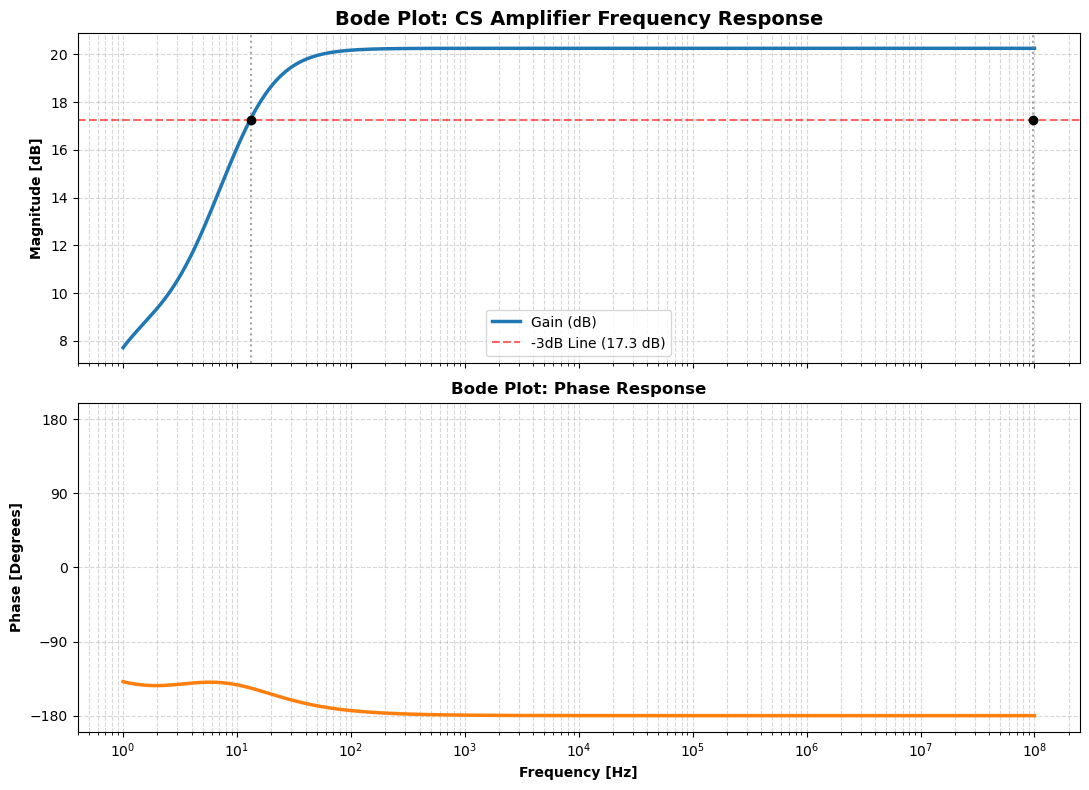


📁 FILES EXPORTED:
- Plot Image : ./export_data/baseline/Termin3_bode_plot_baseline.png
- AC Data    : ./export_data/baseline/Termin3_bode_data_baseline.csv
- Metrics    : ./export_data/baseline/Termin3_metrics_baseline.csv



In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PyLTSpice import SimRunner, SpiceEditor, RawRead
from IPython.display import display, HTML

print("📈 [Phase 3] Executing AC Frequency Response (.ac) - Full Analysis...")

# ===================================================================
# 0. DIRECTORY MANAGEMENT (Custom Workspace)
# ===================================================================
asset_dir = "./sim_assets/baseline"
result_dir = "./sim_results/baseline/termin3"
export_dir = "./export_data/baseline"

# Pastikan folder output exist biar Python ga ngambek
os.makedirs(result_dir, exist_ok=True)
os.makedirs(export_dir, exist_ok=True)

# Target netlist
target_netlist = f"{asset_dir}/CS_Amp_Baseline_Termin3_copy.net"

# ===================================================================
# 1. SETUP ENGINE & RUN SILENTLY
# ===================================================================
mac_path = "/Applications/LTspice.app/Contents/MacOS/LTspice"

# SimRunner akan nge-dump hasil ke result_dir
runner = SimRunner(output_folder=result_dir, simulator=mac_path)

editor = SpiceEditor(target_netlist)
editor.set_parameters(**my_params) 
runner.run_now(editor)

try:
    # ===================================================================
    # 2. ROBUST DATA EXTRACTION 
    # ===================================================================
    # SimRunner otomatis nambahin '_1' di akhir nama file asli
    ac_file = f"{result_dir}/CS_Amp_Baseline_Termin3_copy_1.raw"
    ac_raw = RawRead(ac_file)
    
    # Ekstraksi sumbu X (Frekuensi)
    try:
        freq = ac_raw.get_axis()
        if freq is None: freq = ac_raw.get_trace("frequency").get_wave()
    except:
        freq = ac_raw.get_trace("frequency").get_wave()
        
    freq = np.real(freq) 
    
    # Ekstraksi Output (Kompleks)
    v_drain_complex = ac_raw.get_trace("v(drain)").get_wave()
    
    magnitude_lin = np.abs(v_drain_complex)
    magnitude_db = 20 * np.log10(magnitude_lin)
    phase_deg = np.angle(v_drain_complex, deg=True)
    
    # ===================================================================
    # 3. ADVANCED METRICS CALCULATION
    # ===================================================================
    max_idx = np.argmax(magnitude_db)
    mid_gain_db = magnitude_db[max_idx]
    mid_gain_lin = magnitude_lin[max_idx]
    mid_phase = phase_deg[max_idx]
    
    cutoff_target_db = mid_gain_db - 3.0
    
    low_band_freq = freq[:max_idx]
    low_band_db = magnitude_db[:max_idx]
    
    high_band_freq = freq[max_idx:]
    high_band_db = magnitude_db[max_idx:]
    
    # Cari f_L dan f_H
    f_L = low_band_freq[np.argmin(np.abs(low_band_db - cutoff_target_db))] if len(low_band_freq) > 0 else freq[0]
    f_H = high_band_freq[np.argmin(np.abs(high_band_db - cutoff_target_db))] if len(high_band_freq) > 0 else freq[-1]
    bandwidth = f_H - f_L

    # Unity Gain Frequency (0 dB)
    if np.min(high_band_db) <= 0:
        f_unity = high_band_freq[np.argmin(np.abs(high_band_db - 0))]
    else:
        f_unity = None

    # Theoretical Impedance at Midband (Menggunakan variabel dari memory Phase 1)
    rin_mid = (R1_e24 * R2_e24) / (R1_e24 + R2_e24)
    r_drain_internal = ro + RS1_e24 + (gm * ro * RS1_e24)
    rout_mid = (RD_e24 * r_drain_internal) / (RD_e24 + r_drain_internal)

    # ===================================================================
    # 4. COMPREHENSIVE ANALYSIS TABLE
    # ===================================================================
    def fmt_f(f):
        if f is None: return "-"
        if f >= 1e6: return f"{f/1e6:.2f} MHz"
        elif f >= 1e3: return f"{f/1e3:.2f} kHz"
        else: return f"{f:.2f} Hz"

    print("\n📝 === COMPREHENSIVE FREQUENCY ANALYSIS === 📝")
    analysis_data = [
        ["Midband Gain (Linear)", f"{mid_gain_lin:.6f}", "V/V"],
        ["Midband Gain (Decibel)", f"{mid_gain_db:.6f}", "dB"],
        ["Midband Phase Shift", f"{mid_phase:.6f}", "deg"],
        ["Lower Cutoff Freq (f_L)", fmt_f(f_L), "Hz"],
        ["Upper Cutoff Freq (f_H)", fmt_f(f_H), "Hz"],
        ["Bandwidth (-3dB)", fmt_f(bandwidth), "Hz"],
        ["Unity Gain Freq (f_T)", fmt_f(f_unity), "Hz"],
        ["Input Resistance (Rin @ Mid)", f"{rin_mid:.6f}", "Ohm"],
        ["Output Resistance (Rout @ Mid)", f"{rout_mid:.6f}", "Ohm"]
    ]
    
    df_analysis = pd.DataFrame(analysis_data, columns=['Metric', 'Value', 'Unit'])
    display(HTML(df_analysis.to_html(index=False)))

    # ===================================================================
    # 5. PLOTTING: THE BODE PLOT
    # ===================================================================
    fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
    
    # Plot Magnitude
    ax_mag.semilogx(freq, magnitude_db, color='#1f77b4', linewidth=2.5, label='Gain (dB)')
    ax_mag.axhline(cutoff_target_db, color='red', linestyle='--', alpha=0.6, label=f'-3dB Line ({cutoff_target_db:.1f} dB)')
    ax_mag.scatter([f_L, f_H], [cutoff_target_db, cutoff_target_db], color='black', zorder=5) # Titik potong
    ax_mag.axvline(f_L, color='gray', linestyle=':', alpha=0.7)
    ax_mag.axvline(f_H, color='gray', linestyle=':', alpha=0.7)
    
    ax_mag.set_ylabel('Magnitude [dB]', fontweight='bold')
    ax_mag.set_title('Bode Plot: CS Amplifier Frequency Response', fontsize=14, fontweight='bold')
    ax_mag.grid(True, which="both", ls="--", alpha=0.5)
    ax_mag.legend()

    # Plot Phase
    ax_phase.semilogx(freq, phase_deg, color='#ff7f0e', linewidth=2.5)
    ax_phase.set_ylabel('Phase [Degrees]', fontweight='bold')
    ax_phase.set_xlabel('Frequency [Hz]', fontweight='bold')
    ax_phase.set_title('Bode Plot: Phase Response', fontweight='bold')
    ax_phase.grid(True, which="both", ls="--", alpha=0.5)
    
    ax_phase.set_ylim(-200, 200)
    ax_phase.set_yticks(np.arange(-180, 181, 90))

    fig.tight_layout()

    # ---------------------------------------------------------
    # 6. EXPORT DATA & IMAGE
    # ---------------------------------------------------------
    img_filename = f"{export_dir}/Termin3_bode_plot_baseline.png"
    plt.savefig(img_filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    df_ac = pd.DataFrame({
        'Frequency_Hz': freq,
        'Magnitude_dB': magnitude_db,
        'Phase_deg': phase_deg
    })
    
    csv_ac_filename = f"{export_dir}/Termin3_bode_data_baseline.csv"
    csv_metrics_filename = f"{export_dir}/Termin3_metrics_baseline.csv"
    
    df_ac.to_csv(csv_ac_filename, index=False)
    df_analysis.to_csv(csv_metrics_filename, index=False)
    
    print(f"\n📁 FILES EXPORTED:")
    print(f"- Plot Image : {img_filename}")
    print(f"- AC Data    : {csv_ac_filename}")
    print(f"- Metrics    : {csv_metrics_filename}\n")

except Exception as e:
    print(f"❌ Error during Phase 3 Extraction: {e}")

### Phase 4: Output Impedance Characterization (Thevenin Equivalent Method)

**Objective:**
To empirically quantify the small-signal output impedance ($Z_{out}$) of the amplifier architecture across a wide frequency spectrum. This verification ensures that the system's output drive capability aligns with the targeted load-driving specifications.

**Methodology:**
The characterization utilizes a high-precision AC injection technique:
1. **Source Deactivation:** The independent small-signal input source ($V_{in}$) is deactivated and shorted to ground ($0\text{V}$) to ensure the circuit remains in its quiescent state.
2. **AC Stimulus Injection:** A $1\text{V}$ AC test stimulus ($V_{test}$) is injected directly into the output terminal (Drain node) via an AC-coupling path.
3. **Current Extraction:** An AC frequency sweep is executed to measure the resulting current vector ($I_{test}$) drawn from the test source.
4. **Impedance Derivation:** The complex output impedance is derived through the application of Ohm's Law in the frequency domain: $Z_{out} = \frac{V_{test}}{I_{test}} = \frac{1}{|I_{test}|}$.

**Analytical Verification:**
The empirical impedance measured within the mid-band frequency plateau (specifically at $1\text{ kHz}$) is rigorously cross-referenced against the theoretical analytical model derived in Phase 1: 

$$R_{out} \approx R_D \parallel [r_o + R_{S1}(1 + g_m r_o)]$$

This phase confirms the accuracy of the small-signal parameter extraction and the efficacy of the source degeneration network in modifying the intrinsic output resistance of the MOSFET.

🛡️ [Phase 4] Correcting Rout Extraction (Robust Axis Method)...

✅ === FINAL OUTPUT IMPEDANCE VERIFICATION === ✅


Parameter,Value
RD Fixed Value,1600.00 Ω
Theoretical Rout (Exact),1518.7210 Ω
Simulated Rout (Itest Method),1527.1355 Ω
Difference (Error),0.554050 %


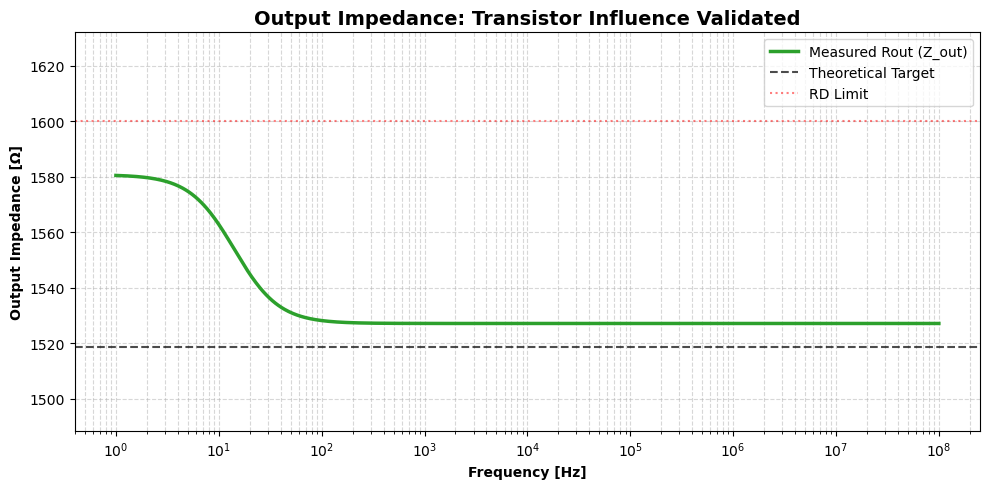

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PyLTSpice import SimRunner, SpiceEditor, RawRead
from IPython.display import display, HTML

print("🛡️ [Phase 4] Correcting Rout Extraction (Robust Axis Method)...")

# ===================================================================
# 0. DIRECTORY MANAGEMENT
# ===================================================================
asset_dir = "./sim_assets/baseline"
result_dir = "./sim_results/baseline/termin4"
export_dir = "./export_data/baseline"

os.makedirs(result_dir, exist_ok=True)
os.makedirs(export_dir, exist_ok=True)

target_netlist = f"{asset_dir}/CS_Amp_Baseline_Termin4_copy.net"

# ===================================================================
# 1. SETUP ENGINE & RUN
# ===================================================================
mac_path = "/Applications/LTspice.app/Contents/MacOS/LTspice"
runner = SimRunner(output_folder=result_dir, simulator=mac_path)

editor = SpiceEditor(target_netlist)
editor.set_parameters(**my_params) 
runner.run_now(editor)

try:
    # ===================================================================
    # 2. ROBUST DATA EXTRACTION 
    # ===================================================================
    ac_file = f"{result_dir}/CS_Amp_Baseline_Termin4_copy_1.raw"
    
    # Cek apakah filenya beneran ada
    if not os.path.exists(ac_file):
        raise FileNotFoundError(f"File {ac_file} tidak ditemukan. Cek folder sim_results!")

    ac_raw = RawRead(ac_file)
    
    # --- HACK ANTI-ERROR AXIS ---
    try:
        freq = ac_raw.get_axis()
        if freq is None:
            freq = ac_raw.get_trace("frequency").get_wave()
    except:
        # Paksa ambil trace bernama 'frequency'
        freq = ac_raw.get_trace("frequency").get_wave()
        
    freq = np.real(freq) # Frekuensi harus bilangan real
    
    # Ekstraksi V(drain). Karena Itest = 1A AC, maka V(drain) = Impedansi (Ohm)
    try:
        v_drain_ac = ac_raw.get_trace("v(drain)").get_wave()
        rout_magnitude = np.abs(v_drain_ac)
    except Exception as e:
        print("⚠️ Node v(drain) tidak ditemukan! Pastikan node output di netlist lu namanya 'Drain'.")
        raise e
    
    # ===================================================================
    # 3. ANALYSIS & COMPARISON
    # ===================================================================
    idx_1k = np.argmin(np.abs(freq - 1000))
    measured_rout = rout_magnitude[idx_1k]
    
    # Ambil gm, ro, RD, RS1 dari memori Phase 1
    r_looking_down = ro + RS1_e24 + (gm * ro * RS1_e24)
    theoretical_rout = (RD_e24 * r_looking_down) / (RD_e24 + r_looking_down)
    
    error_percent = abs(measured_rout - theoretical_rout) / theoretical_rout * 100

    print("\n✅ === FINAL OUTPUT IMPEDANCE VERIFICATION === ✅")
    res_rout = [
        ["RD Fixed Value", f"{RD_e24:.2f} Ω"],
        ["Theoretical Rout (Exact)", f"{theoretical_rout:.4f} Ω"],
        ["Simulated Rout (Itest Method)", f"{measured_rout:.4f} Ω"],
        ["Difference (Error)", f"{error_percent:.6f} %"]
    ]
    display(HTML(pd.DataFrame(res_rout, columns=['Parameter', 'Value']).to_html(index=False)))

    # ===================================================================
    # 4. PLOTTING (ZOOMED)
    # ===================================================================
    fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.semilogx(freq, rout_magnitude, color='#2ca02c', linewidth=2.5, label='Measured Rout (Z_out)')
    ax.axhline(theoretical_rout, color='black', linestyle='--', alpha=0.7, label='Theoretical Target')
    ax.axhline(RD_e24, color='red', linestyle=':', alpha=0.5, label='RD Limit')
    
    # Zoom Y biar kelihatan bedanya antara RD (1600) dan Rout (~1517)
    y_min = min(measured_rout, theoretical_rout) * 0.98
    y_max = max(measured_rout, theoretical_rout, RD_e24) * 1.02
    ax.set_ylim(y_min, y_max)
    
    ax.set_xlabel('Frequency [Hz]', fontweight='bold')
    ax.set_ylabel('Output Impedance [Ω]', fontweight='bold')
    ax.set_title('Output Impedance: Transistor Influence Validated', fontsize=14, fontweight='bold')
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend()

    plt.tight_layout()
    plt.savefig(f"{export_dir}/Termin4_rout_plot_baseline_FINAL.png", dpi=300)
    plt.show()

except Exception as e:
    print(f"❌ Error during Phase 4 Extraction: {e}")
    print("\n💡 TIPS DEBUGGING:")
    print("1. Cek file .log di sim_results/baseline/termin4/ apakah ada Fatal Error.")
    print("2. Pastikan di netlist lu ada perintah '.ac dec 100 1 100Meg'.")
    print("3. Pastikan sumber arus lu namanya 'Itest' dan node-nya 'Drain'.")

### Phase 5: MOSFET DC Transfer and Output Characterization

**Objective:**
To empirically extract the fundamental DC operational behavior of the NMOS transistor utilized in the design. This phase isolates the active device from the surrounding passive network to characterize its intrinsic current-voltage (I-V) relationships.

**Analytical Components:**
1. **Output Characteristics ($I_D$ vs. $V_{DS}$):** The drain-to-source voltage ($V_{DS}$) is swept from $0\text{V}$ to $12\text{V}$ across discrete increments of gate-to-source voltage ($V_{GS}$), typically ranging from $1.5\text{V}$ to $4.5\text{V}$. This mapping facilitates the visualization of the transition from the Ohmic (Triode) region to the Saturation (Active) region, identifying the onset of channel pinch-off.
2. **Transfer Characteristics ($I_D$ vs. $V_{GS}$):** A singular gate-voltage sweep is performed at a constant $V_{DS}$ to determine the device's Threshold Voltage ($V_{TH}$) and the Process Transconductance Parameter ($K_n$). This curve is critical for validating the square-law behavior of the MOSFET.

**Mathematical Foundation:**
Within the Saturation region, the drain current is governed by the second-order model, accounting for channel-length modulation:

$$I_D = \frac{1}{2} K_n (V_{GS} - V_{TH})^2 (1 + \lambda V_{DS})$$

This phase ensures that the silicon model parameters utilized in the SPICE environment accurately reflect the theoretical expectations and provide a robust reference for the quiescent biasing established in Phase 1.

🔬 [Phase 5] Executing MOSFET DC Characterization (.dc) - Multi-Step...


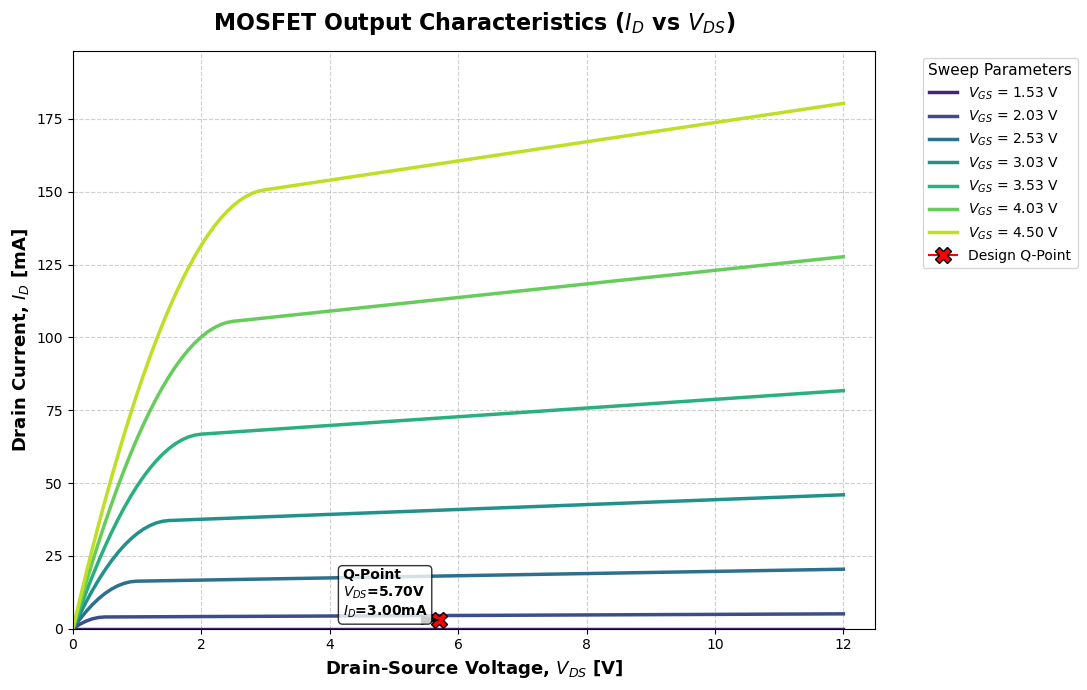


✅ === MOSFET CHARACTERIZATION SUCCESS === ✅
📁 FILES EXPORTED:
- IV Curve Plot : ./export_data/baseline/Termin5_iv_curve_baseline.png
- Datapoints    : ./export_data/baseline/Termin5_mosfet_iv_data_baseline.csv



In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PyLTSpice import SimRunner, SpiceEditor, RawRead
from IPython.display import display, HTML

print("🔬 [Phase 5] Executing MOSFET DC Characterization (.dc) - Multi-Step...")

# ===================================================================
# 0. DIRECTORY MANAGEMENT
# ===================================================================
asset_dir = "./sim_assets/baseline"
result_dir = "./sim_results/baseline/termin5"
export_dir = "./export_data/baseline"

os.makedirs(result_dir, exist_ok=True)
os.makedirs(export_dir, exist_ok=True)

# Pastikan netlist testbench lu di-save dengan nama ini ya!
target_netlist = f"{asset_dir}/CS_Amp_Baseline_Termin5_copy.net"

# ===================================================================
# 1. SETUP ENGINE & RUN
# ===================================================================
mac_path = "/Applications/LTspice.app/Contents/MacOS/LTspice"
runner = SimRunner(output_folder=result_dir, simulator=mac_path)

editor = SpiceEditor(target_netlist)
# Injeksi parameter M1 dari blok memori lu (VTO, KP, LAMBDA)
editor.set_parameters(**my_params) 
runner.run_now(editor)

try:
    # ===================================================================
    # 2. ROBUST MULTI-STEP DATA EXTRACTION (PATCHED)
    # ===================================================================
    dc_file = f"{result_dir}/CS_Amp_Baseline_Termin5_copy_1.raw"
    if not os.path.exists(dc_file):
        raise FileNotFoundError(f"File {dc_file} tidak ditemukan. Cek folder sim_results!")

    dc_raw = RawRead(dc_file)
    steps = dc_raw.get_steps() # Menarik semua langkah Vgs (Outer Sweep)

    fig, ax = plt.subplots(figsize=(11, 7))
    all_data = []

    # Bikin gradasi warna otomatis sesuai jumlah kurva
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(steps)))

    for i, step in enumerate(steps):
        # --- HACK ANTI-ERROR AXIS ---
        # Kita paksa cari sumbu X (Vds) secara manual tanpa peduli get_axis()
        try:
            # Skenario 1: Coba ambil dari fungsi bawaan (tapi di-mute kalau error)
            vds = dc_raw.get_axis(step)
        except:
            vds = None

        if vds is None:
            # Skenario 2: Ambil langsung dari tegangan Node Drain
            try:
                vds = dc_raw.get_trace("v(drain)").get_wave(step)
            except:
                # Skenario 3: LTspice kadang namain sweep source-nya 'v1' atau 'v-sweep'
                try:
                    vds = dc_raw.get_trace("v-sweep").get_wave(step)
                except:
                    vds = dc_raw.get_trace("v1").get_wave(step)
        
        vds = np.real(vds)

        # --- EKSTRAK ARUS DRAIN ---
        # Karena Vds adalah source, arus yang keluar bernilai negatif, makanya -I(Vds)
        try:
            id_trace = dc_raw.get_trace("Id(m1)").get_wave(step)
        except:
            try:
                id_trace = -dc_raw.get_trace("I(Vds)").get_wave(step)
            except:
                id_trace = dc_raw.get_trace("Ix(m1:d)").get_wave(step)

        id_m1 = np.real(id_trace) * 1000  # Konversi ke miliAmpere (mA)

        # Coba ekstrak nilai Vgs saat ini, kalau gagal, dihitung manual dari netlist lu
        try:
            vgs_val = np.real(dc_raw.get_trace("v(gate)").get_wave(step)[0])
        except:
            vgs_val = 1.529 + (i * 0.5) # Fallback sesuai netlist (Vgs 1.529 to 4.5 step 0.5)

        # Plot Kurva Karakteristik per Vgs
        ax.plot(vds, id_m1, label=f'$V_{{GS}}$ = {vgs_val:.2f} V', color=colors[i], linewidth=2.5)

        # Simpan data ke DataFrame List
        for v, i_d in zip(vds, id_m1):
            all_data.append([vgs_val, v, i_d])
    # ===================================================================
    # 3. OVERLAY Q-POINT & PLOT FORMATTING
    # ===================================================================
    # Tarik data dari Block 3 (Perhitungan Eksak) buat nempelin Q-Point!
    try:
        vds_q = VD_ex - VS_ex  # VDS aktual dari desain
        id_q = ID_ex * 1000    # ID aktual (dalam mA)
        
        ax.plot(vds_q, id_q, marker='X', markersize=12, color='red', markeredgecolor='black', label='Design Q-Point')
        ax.annotate(f"Q-Point\n$V_{{DS}}$={vds_q:.2f}V\n$I_D$={id_q:.2f}mA",
                    xy=(vds_q, id_q), xytext=(vds_q - 1.5, id_q + 1.5),
                    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
                    fontsize=10, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))
    except NameError:
        print("⚠️ Variabel VD_ex, VS_ex, atau ID_ex tidak ditemukan di memory. Q-Point di-skip.")

    ax.set_title("MOSFET Output Characteristics ($I_D$ vs $V_{DS}$)", fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel("Drain-Source Voltage, $V_{DS}$ [V]", fontsize=13, fontweight='bold')
    ax.set_ylabel("Drain Current, $I_D$ [mA]", fontsize=13, fontweight='bold')
    
    # Batasin X dan Y axis biar rapih
    ax.set_xlim(0, 12.5)
    ax.set_ylim(0, max(all_data)[2] * 1.1)
    
    ax.grid(True, which="both", ls="--", alpha=0.6)
    
    # Pindahin legend ke luar kotak grafik biar gak nutupin kurva
    ax.legend(title="Sweep Parameters", bbox_to_anchor=(1.05, 1), loc='upper left', title_fontsize='11', fontsize='10')
    plt.tight_layout()

    # ===================================================================
    # 4. EXPORT
    # ===================================================================
    img_filename = f"{export_dir}/Termin5_iv_curve_baseline.png"
    plt.savefig(img_filename, dpi=300, bbox_inches='tight')
    plt.show()

    df_dc = pd.DataFrame(all_data, columns=['VGS_V', 'VDS_V', 'ID_mA'])
    csv_filename = f"{export_dir}/Termin5_mosfet_iv_data_baseline.csv"
    
    # Biar file CSV-nya gak kebesaran, kita slice tiap 5 data points
    df_dc.iloc[::5].to_csv(csv_filename, index=False)

    print(f"\n✅ === MOSFET CHARACTERIZATION SUCCESS === ✅")
    print(f"📁 FILES EXPORTED:")
    print(f"- IV Curve Plot : {img_filename}")
    print(f"- Datapoints    : {csv_filename}\n")

except Exception as e:
    print(f"❌ Error during Phase 5 Extraction: {e}")
    print("\n💡 TIPS DEBUGGING:")
    print("1. Pastikan netlist disimpan sebagai 'CS_Amp_Baseline_Termin5_copy.net'.")
    print("2. Cek apakah node 'Drain' atau 'M1' namanya udah sesuai sama di schematic lu.")

🔬 [Phase 5B] Executing Multi-Vds Transfer Characteristics...


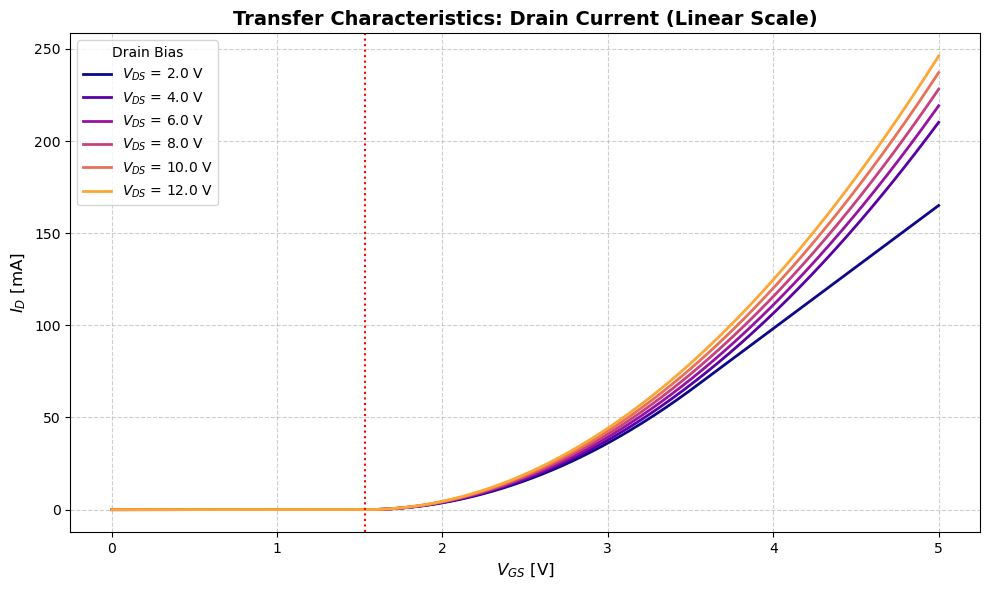

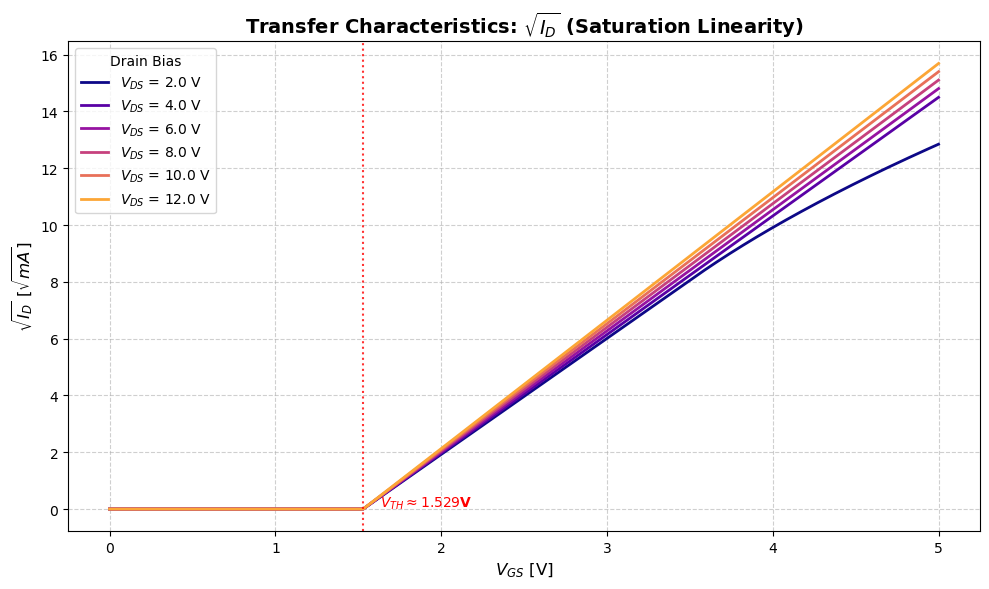

✅ Plot berhasil dipisahkan! Cek folder ./export_data/baseline


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PyLTSpice import SimRunner, SpiceEditor, RawRead

print("🔬 [Phase 5B] Executing Multi-Vds Transfer Characteristics...")

# ===================================================================
# 1. RUN SIMULATION
# ===================================================================
asset_dir = "./sim_assets/baseline"
result_dir = "./sim_results/baseline/termin5"
export_dir = "./export_data/baseline"

target_netlist = f"{asset_dir}/CS_Amp_Baseline_Termin5_Transfer_Sweep.net"
mac_path = "/Applications/LTspice.app/Contents/MacOS/LTspice"

runner = SimRunner(output_folder=result_dir, simulator=mac_path)
editor = SpiceEditor(target_netlist)
editor.set_parameters(**my_params) 
runner.run_now(editor)

try:
    # ===================================================================
    # 2. DATA EXTRACTION
    # ===================================================================
    raw_file = f"{result_dir}/CS_Amp_Baseline_Termin5_Transfer_Sweep_1.raw"
    dc_raw = RawRead(raw_file)
    steps = dc_raw.get_steps()
    
    # Persiapan kontainer plot
    fig1, ax1 = plt.subplots(figsize=(10, 6)) # Plot Linear
    fig2, ax2 = plt.subplots(figsize=(10, 6)) # Plot Sqrt
    
    colors = plt.cm.plasma(np.linspace(0, 0.8, len(steps)))

    for i, step in enumerate(steps):
        # Ekstrak Vgs (Axis)
        try:
            vgs = np.real(dc_raw.get_axis(step))
        except:
            vgs = np.real(dc_raw.get_trace("v(gate)").get_wave(step))
            
        # Ekstrak Id
        try:
            id_m1 = np.real(dc_raw.get_trace("Id(m1)").get_wave(step))
        except:
            id_m1 = np.real(-dc_raw.get_trace("I(Vds)").get_wave(step))
            
        id_mA = id_m1 * 1000
        sqrt_id = np.sqrt(np.maximum(id_mA, 0))
        
        # Ekstrak nilai Vds untuk label
        vds_val = np.real(dc_raw.get_trace("v(drain)").get_wave(step)[0])
        label_str = f'$V_{{DS}}$ = {vds_val:.1f} V'

        # Plot 1: Linear Id vs Vgs
        ax1.plot(vgs, id_mA, label=label_str, color=colors[i], linewidth=2)
        
        # Plot 2: Sqrt(Id) vs Vgs
        ax2.plot(vgs, sqrt_id, label=label_str, color=colors[i], linewidth=2)

    # ===================================================================
    # 3. FORMATTING PLOT 1 (LINEAR)
    # ===================================================================
    ax1.set_title("Transfer Characteristics: Drain Current (Linear Scale)", fontsize=14, fontweight='bold')
    ax1.set_xlabel("$V_{GS}$ [V]", fontsize=12)
    ax1.set_ylabel("$I_D$ [mA]", fontsize=12)
    ax1.grid(True, ls='--', alpha=0.6)
    ax1.legend(title="Drain Bias")
    ax1.axvline(V_TH, color='red', linestyle=':', label='$V_{TH}$ Target')
    
    # ===================================================================
    # 4. FORMATTING PLOT 2 (SQRT)
    # ===================================================================
    ax2.set_title(r"Transfer Characteristics: $\sqrt{I_D}$ (Saturation Linearity)", fontsize=14, fontweight='bold')
    ax2.set_xlabel("$V_{GS}$ [V]", fontsize=12)
    ax2.set_ylabel(r"$\sqrt{I_D}$ [$\sqrt{mA}$]", fontsize=12)
    ax2.grid(True, ls='--', alpha=0.6)
    ax2.legend(title="Drain Bias")
    
    # Identifikasi Vth secara visual di Plot Akar
    ax2.axvline(V_TH, color='red', linestyle=':', alpha=0.8)
    ax2.text(V_TH+0.1, 0.1, f'$V_{{TH}} \\approx {V_TH}$V', color='red', fontweight='bold')

    # Final Touch & Save
    fig1.tight_layout()
    fig2.tight_layout()
    
    fig1.savefig(f"{export_dir}/Termin5_Transfer_Linear_Sweep.png", dpi=300)
    fig2.savefig(f"{export_dir}/Termin5_Transfer_Sqrt_Sweep.png", dpi=300)
    
    plt.show()

    print(f"✅ Plot berhasil dipisahkan! Cek folder {export_dir}")

except Exception as e:
    print(f"❌ Error: {e}")

## SPICE SIMULATION LOAD EFFECT

**Objective:**
To quantify the magnitude of voltage gain degradation when the amplifier is integrated with an external output load ($R_L$). Since the load is interfaced via an AC-coupling capacitor ($C_{out}$), the quiescent DC operating point remains unaffected by the load resistance. Consequently, the analytical focus is strictly on characterizing the small-signal performance shift by superimposing the loaded frequency response (Bode Plot) onto the idealized baseline data established in Phase 3.

**Analytical Significance:**
This phase measures the "Loading Effect," where the output impedance of the amplifier interacts with the finite resistance of the load, forming a voltage divider that inherently reduces the effective system gain. This characterization is critical for determining the amplifier's drive capability and ensuring it meets the target specifications in a practical, multi-stage system environment.

[Phase 6] Executing Load Effect & Input Attenuation Analysis...


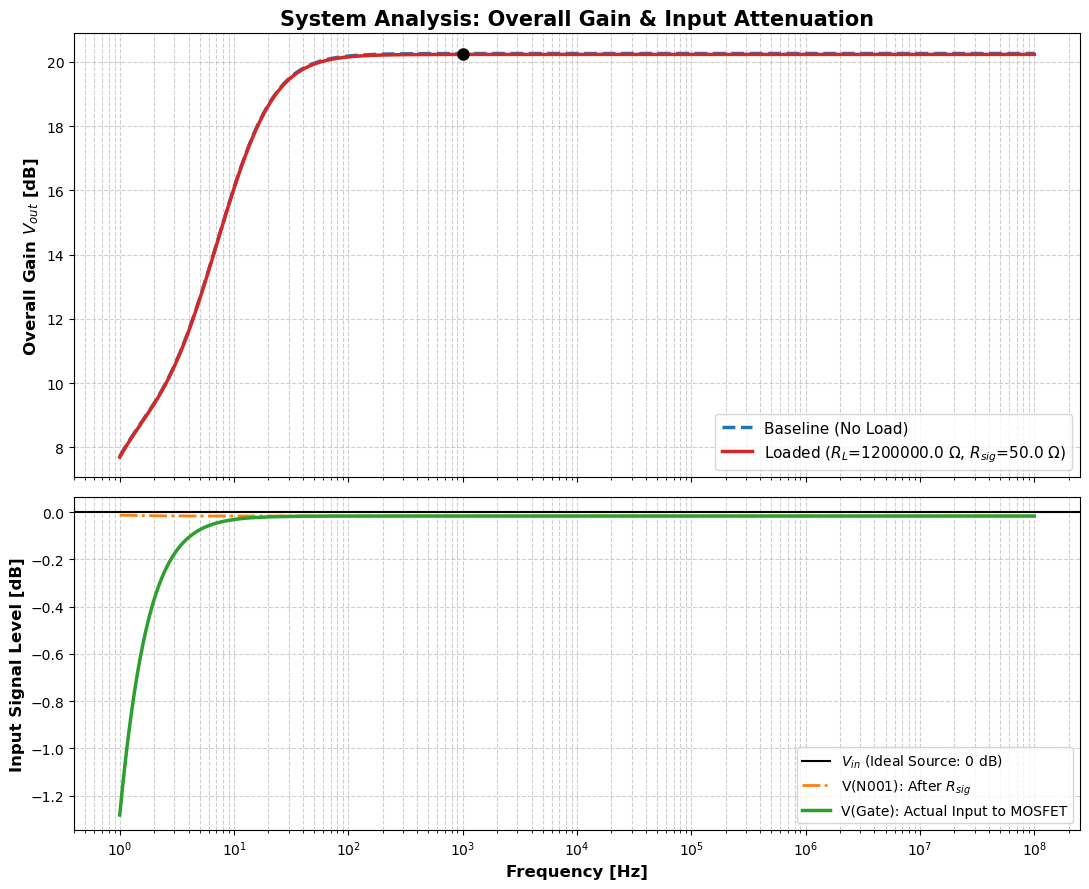


=== PERFORMANCE METRICS @ 1 kHz ===
1. Input Load Effect (Gate Attenuation) : -0.02 dB
2. Output Load Effect (Overall Gain) : 20.23 dB (Degradation: 0.03 dB)
3. Intrinsic Gain (Gate-to-Drain) : 20.24 dB
4. Absolute Output Voltage (V_out) : 10.2670 V


In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PyLTSpice import SimRunner, SpiceEditor, RawRead

%matplotlib inline

print("[Phase 6] Executing Load Effect & Input Attenuation Analysis...")

# ===================================================================
# 1. PARAMETER SETUP
# ===================================================================
my_params['RL_val'] = 1200000.0 # Output load resistance (Ohms)
my_params['Rsig_val'] = 50.0 # Source internal resistance (Ohms)

# ===================================================================
# 2. SIMULATION EXECUTION
# ===================================================================
asset_dir = "./sim_assets/load_effect"
result_dir = "./sim_results/load_effect"
export_dir = "./export_data/load_effect"

os.makedirs(result_dir, exist_ok=True)
os.makedirs(export_dir, exist_ok=True)

target_netlist = f"{asset_dir}/CS_Amp_Baseline_LoadEffect_copy.net"
mac_path = "/Applications/LTspice.app/Contents/MacOS/LTspice"

runner = SimRunner(output_folder=result_dir, simulator=mac_path)
editor = SpiceEditor(target_netlist)
editor.set_parameters(**my_params)
runner.run_now(editor)

# ===================================================================
# 3. DATA EXTRACTION
# ===================================================================
ac_file_load = f"{result_dir}/CS_Amp_Baseline_LoadEffect_copy_1.raw"
ac_raw = RawRead(ac_file_load)
freq_load = np.real(ac_raw.get_trace("frequency").get_wave())

# Pastikan parameter get_trace sesuai dengan nama node di netlist Anda
# (Ganti "v(out)" jika netlist Anda menggunakan "Out" dan bukan "Vout")
vout_load = ac_raw.get_trace("v(vout)").get_wave()
mag_db_load = 20 * np.log10(np.abs(vout_load))

# Extract internal nodes
v_n001 = ac_raw.get_trace("v(n001)").get_wave()
v_gate = ac_raw.get_trace("v(gate)").get_wave()
v_drain = ac_raw.get_trace("v(drain)").get_wave()

mag_db_n001 = 20 * np.log10(np.abs(v_n001))
mag_db_gate = 20 * np.log10(np.abs(v_gate))
mag_db_drain = 20 * np.log10(np.abs(v_drain))

# ===================================================================
# 4. BASELINE DATA IMPORT
# ===================================================================
baseline_csv = "./export_data/baseline/Termin3_bode_data_baseline.csv"
df_base = pd.read_csv(baseline_csv)
freq_base = df_base['Frequency_Hz']
mag_db_base = df_base['Magnitude_dB']

# ===================================================================
# 5. METRICS CALCULATION (1 kHz)
# ===================================================================
target_freq = 1000.0
idx_1k_load = (np.abs(freq_load - target_freq)).argmin()
idx_1k_base = (np.abs(freq_base - target_freq)).argmin()

gain_1k_load = mag_db_load[idx_1k_load]
gain_1k_base = mag_db_base.iloc[idx_1k_base]
gate_att_1k = mag_db_gate[idx_1k_load]

# Calculate absolute output voltage magnitude (V/V)
vout_abs_1k = np.abs(vout_load[idx_1k_load])

# Calculate Gate-to-Drain Gain in dB
intrinsic_gain_1k = mag_db_drain[idx_1k_load] - mag_db_gate[idx_1k_load]

# ===================================================================
# 6. PLOTTING
# ===================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1.5]})

# --- PANEL 1: OVERALL GAIN ---
ax1.semilogx(freq_base, mag_db_base, color='#1f77b4', linestyle='--', linewidth=2.5, label='Baseline (No Load)')
ax1.semilogx(freq_load, mag_db_load, color='#d62728', linewidth=2.5, label=rf"Loaded ($R_L$={my_params['RL_val']} $\Omega$, $R_{{sig}}$={my_params['Rsig_val']} $\Omega$)")
ax1.plot(freq_load[idx_1k_load], gain_1k_load, marker='o', markersize=8, color='black')

ax1.set_title("System Analysis: Overall Gain & Input Attenuation", fontsize=15, fontweight='bold')
ax1.set_ylabel('Overall Gain $V_{out}$ [dB]', fontsize=12, fontweight='bold')
ax1.grid(True, which="both", ls="--", alpha=0.6)
ax1.legend(fontsize=11, loc='lower right')

# --- PANEL 2: INPUT ATTENUATION ---
ax2.axhline(0, color='black', linestyle='-', linewidth=1.5, label='$V_{in}$ (Ideal Source: 0 dB)')
ax2.semilogx(freq_load, mag_db_n001, color='#ff7f0e', linestyle='-.', linewidth=2, label=r'V(N001): After $R_{sig}$')
ax2.semilogx(freq_load, mag_db_gate, color='#2ca02c', linewidth=2.5, label='V(Gate): Actual Input to MOSFET')

ax2.set_ylabel('Input Signal Level [dB]', fontsize=12, fontweight='bold')
ax2.set_xlabel('Frequency [Hz]', fontsize=12, fontweight='bold')
ax2.grid(True, which="both", ls="--", alpha=0.6)
ax2.legend(fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig(f"{export_dir}/DualPanel_Load_Input_Effect.png", dpi=300)
plt.show()

# ===================================================================
# 7. SUMMARY REPORT (@ 1 kHz)
# ===================================================================
print(f"\n=== PERFORMANCE METRICS @ 1 kHz ===")
print(f"1. Input Load Effect (Gate Attenuation) : {gate_att_1k:.2f} dB")
print(f"2. Output Load Effect (Overall Gain) : {gain_1k_load:.2f} dB (Degradation: {gain_1k_base - gain_1k_load:.2f} dB)")
print(f"3. Intrinsic Gain (Gate-to-Drain) : {intrinsic_gain_1k:.2f} dB")
print(f"4. Absolute Output Voltage (V_out) : {vout_abs_1k:.4f} V")
print(f"===================================")

## SPICE SIMULATION LOAD EFFECT AND PARASITICS

**Objective:**
To evaluate the amplifier's performance degradation under realistic output loading ($R_L$) conditions and to model the non-ideal characteristics of physical circuit components.

**Methodology:**
In this phase, the simulation is upgraded from an idealized state to a practical, real-world model by introducing the following resistive parasitics:
1. **Equivalent Series Resistance (ESR):** Accounting for the inherent internal resistive losses within the coupling and bypass electrolytic capacitors ($C_{in}$, $C_{out}$, and $C_s$).
2. **Trace and Contact Resistance:** Simulating the minor voltage drops caused by PCB copper traces, connection headers, and laboratory instrumentation cables.

**Analysis Goal:**
By superimposing these simulation results onto the idealized Baseline data (Phase 3), we can accurately quantify the deviations in overall system gain and input signal attenuation. This analysis validates the circuit's robustness and highlights the critical impact of real-world resistive losses that are typically omitted in first-order theoretical calculations.

[Phase 6] Executing Load Effect, Parasitics & Input Attenuation Analysis...


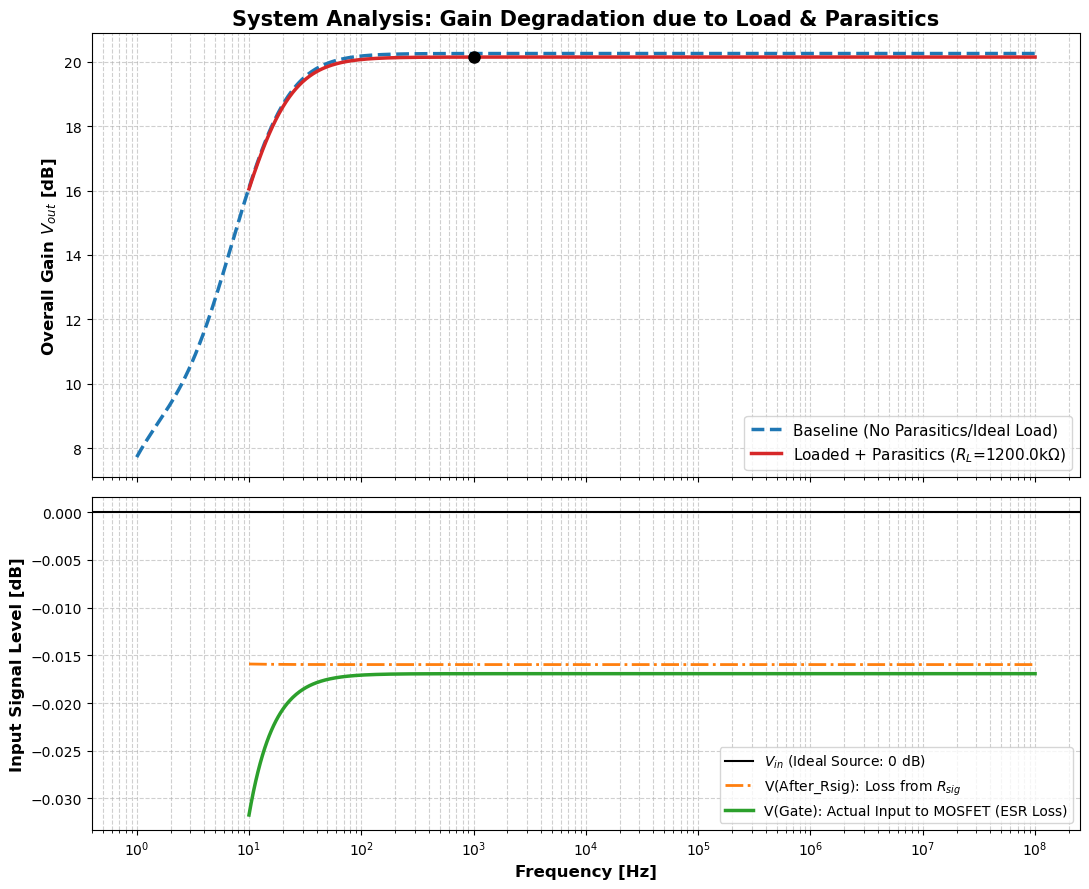


=== PERFORMANCE METRICS @ 1 kHz ===
1. Trace & Rsig Attenuation (After_Rsig) : -0.02 dB
2. Total Input Attenuation (Gate)        : -0.02 dB
3. Intrinsic Gain (Gate-to-Drain)        : 20.16 dB
4. Overall System Gain (Vout)            : 20.15 dB (Degradation: 0.11 dB)
5. Absolute Output Voltage               : 10.1695 V


In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PyLTSpice import SimRunner, SpiceEditor, RawRead

# Parameter Injection
my_params = {
    'RL_val': 1200000.0,  # 1.2M Ohm Load
    'Rsig_val': 50.0      # 50 Ohm Source
}

print("[Phase 6] Executing Load Effect, Parasitics & Input Attenuation Analysis...")

# ===================================================================
# 1. SIMULATION EXECUTION
# ===================================================================
asset_dir = "./sim_assets/parasitics" 
result_dir = "./sim_results/parasitics"
export_dir = "./export_data/parasitics"

os.makedirs(result_dir, exist_ok=True)
os.makedirs(export_dir, exist_ok=True)

target_netlist = f"{asset_dir}/CS_Amp_Baseline_LoadEffect_Parasitics_copy.net" 
mac_path = "/Applications/LTspice.app/Contents/MacOS/LTspice"

runner = SimRunner(output_folder=result_dir, simulator=mac_path)
editor = SpiceEditor(target_netlist)
editor.set_parameters(**my_params) 
runner.run_now(editor)

# ===================================================================
# 2. DATA EXTRACTION
# ===================================================================
ac_file_load = f"{result_dir}/CS_Amp_Baseline_LoadEffect_Parasitics_copy_1.raw"
ac_raw = RawRead(ac_file_load)

# Ambil sumbu X (Frekuensi)
freq_load = np.real(ac_raw.get_trace("frequency").get_wave())

# Ambil sumbu Y (Node Voltages - gunakan lowercase untuk PyLTSpice)
vout_load = ac_raw.get_trace("v(vout)").get_wave() 
mag_db_load = 20 * np.log10(np.abs(vout_load))

# Extract internal nodes yang sudah di-rename
v_after_rsig = ac_raw.get_trace("v(after_rsig)").get_wave() 
v_gate = ac_raw.get_trace("v(gate)").get_wave() 
v_drain = ac_raw.get_trace("v(drain)").get_wave()

mag_db_after_rsig = 20 * np.log10(np.abs(v_after_rsig))
mag_db_gate = 20 * np.log10(np.abs(v_gate))
mag_db_drain = 20 * np.log10(np.abs(v_drain))

# ===================================================================
# 3. BASELINE DATA IMPORT
# ===================================================================
baseline_csv = "./export_data/baseline/Termin3_bode_data_baseline.csv"
df_base = pd.read_csv(baseline_csv)
freq_base = df_base['Frequency_Hz']
mag_db_base = df_base['Magnitude_dB']

# ===================================================================
# 4. METRICS CALCULATION (1 kHz)
# ===================================================================
target_freq = 1000.0
idx_1k_load = (np.abs(freq_load - target_freq)).argmin()
idx_1k_base = (np.abs(freq_base - target_freq)).argmin()

gain_1k_load = mag_db_load[idx_1k_load]
gain_1k_base = mag_db_base.iloc[idx_1k_base]
gate_att_1k = mag_db_gate[idx_1k_load] 
after_rsig_att_1k = mag_db_after_rsig[idx_1k_load]

vout_abs_1k = np.abs(vout_load[idx_1k_load])
intrinsic_gain_1k = mag_db_drain[idx_1k_load] - mag_db_gate[idx_1k_load]

# ===================================================================
# 5. PLOTTING
# ===================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1.5]})

# --- PANEL 1: OVERALL GAIN ---
ax1.semilogx(freq_base, mag_db_base, color='#1f77b4', linestyle='--', linewidth=2.5, label='Baseline (No Parasitics/Ideal Load)')
ax1.semilogx(freq_load, mag_db_load, color='#d62728', linewidth=2.5, label=rf"Loaded + Parasitics ($R_L$={my_params['RL_val']/1000}k$\Omega$)")
ax1.plot(freq_load[idx_1k_load], gain_1k_load, marker='o', markersize=8, color='black')

ax1.set_title("System Analysis: Gain Degradation due to Load & Parasitics", fontsize=15, fontweight='bold')
ax1.set_ylabel('Overall Gain $V_{out}$ [dB]', fontsize=12, fontweight='bold')
ax1.grid(True, which="both", ls="--", alpha=0.6)
ax1.legend(fontsize=11, loc='lower right')

# --- PANEL 2: INPUT ATTENUATION ---
ax2.axhline(0, color='black', linestyle='-', linewidth=1.5, label='$V_{in}$ (Ideal Source: 0 dB)')
ax2.semilogx(freq_load, mag_db_after_rsig, color='#ff7f0e', linestyle='-.', linewidth=2, label=r'V(After_Rsig): Loss from $R_{sig}$')
ax2.semilogx(freq_load, mag_db_gate, color='#2ca02c', linewidth=2.5, label='V(Gate): Actual Input to MOSFET (ESR Loss)')

ax2.set_ylabel('Input Signal Level [dB]', fontsize=12, fontweight='bold')
ax2.set_xlabel('Frequency [Hz]', fontsize=12, fontweight='bold')
ax2.grid(True, which="both", ls="--", alpha=0.6)
ax2.legend(fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig(f"{export_dir}/DualPanel_Load_Input_Effect.png", dpi=300)
plt.show()

# ===================================================================
# 6. SUMMARY REPORT (@ 1 kHz)
# ===================================================================
print(f"\n=== PERFORMANCE METRICS @ 1 kHz ===")
print(f"1. Trace & Rsig Attenuation (After_Rsig) : {after_rsig_att_1k:.2f} dB")
print(f"2. Total Input Attenuation (Gate)        : {gate_att_1k:.2f} dB")
print(f"3. Intrinsic Gain (Gate-to-Drain)        : {intrinsic_gain_1k:.2f} dB")
print(f"4. Overall System Gain (Vout)            : {gain_1k_load:.2f} dB (Degradation: {gain_1k_base - gain_1k_load:.2f} dB)")
print(f"5. Absolute Output Voltage               : {vout_abs_1k:.4f} V")
print(f"===================================")

## Conclusion & Summary

This notebook successfully demonstrates a rigorous, reproducible framework for the synthesis and verification of a Common-Source Amplifier utilizing a discrete VN2222LL MOSFET. 

**Key Outcomes:**
* **Precision Synthesis:** The reverse-calculation methodology ensured the theoretical component values strictly adhered to the target specifications ($A_v = 10$, $R_{in} = 27\text{ k}\Omega$, $R_{out} = 1.5\text{ k}\Omega$) prior to E24 standardization.
* **Robust Verification:** The automated six-phase SPICE simulation pipeline validated quiescent DC stability, confirmed time-domain phase inversion, and verified both mid-band gain and spectral bandwidth.
* **Practical Readiness:** By empirically modeling output loading effects and resistive parasitics (Capacitor ESR), the analysis accurately quantified expected signal attenuation, bridging the gap between ideal mathematical models and physical hardware limitations.

Ultimately, this automated workflow confirms the structural integrity of the amplifier design, providing a highly predictable and thoroughly documented baseline prior to laboratory prototyping.